
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_03_intuicion_estadistica_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Intuición estadística

## Model Selection and Train/Validation/Test Sets
[1] Reference http://cs229.stanford.edu/syllabus.html

Just because a learning algorithm fits a training set well, that does not mean it is a good hypothesis. It could over fit and as a result your predictions on the test set would be poor. The error of your hypothesis as measured on the data set with which you trained the parameters will be lower than the error on any other data set.
Given many models with different complexities (for example polynomial degree), we can use a systematic approach to identify the 'best' function. In order to choose the model of your hypothesis, you can test each degree of polynomial and look at the error result.

One way to break down our dataset into the three sets is:
Training set: 60%
Cross validation set: 20%
Test set: 20%

We can now calculate three separate error values for the three different sets using the following method:
1. Optimize the parameters in Θ using the training set for each polynomial degree.
2. Find the polynomial degree d with the least error using the cross validation set.
3. Estimate the generalization error using the test set with J_{test}

This way, the degree of the polynomial d has not been trained using the test set.



## Para entregar


1. Para los modelos generados en la sesión 3 tomar el 20% como datos para realizar el test y el 80% para realizar el entrenamiento y la validacion cruzada (por ejemplo 70% entrenamiento y 10% validacion cruzada). Construir una curva del score en función del parámetro gamma del clasificador que se esta empleando. ¿Cual presenta una mejor solución al problema?.

2. Construir las curvas de aprendizaje estadístico para el modelo descrito, comprobar que la solución es similar a la que se obtiene a través de sklearn. GridSearch: https://scikit-learn.org/stable/modules/grid_search.html

3. Tomando el mejor modelo para los datos ahora van crear nuevos datasets donde el modelo se espera no va a ser optimo sino que presenta overfitting y underfitting. Elegir, los párametros adecuados para los centros de medias y las matrices de covarianzas y mostrar graficamente un ejemplo de overfitting y uno de underfitting con el modelo óptimo anterior. Analizar los resultados.


---

## Punto 1 — Validation Curve Manual

Construimos una curva del score en función del parámetro `gamma` del SVC con kernel RBF.

**Objetivo**: Encontrar el valor óptimo de gamma que maximiza el score de validación.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split


def generate_gaussian_dataset(
    mean_0, cov_0, mean_1, cov_1, n_samples_per_class, random_state=42
):
    """
    Genera un dataset 2D con dos clases usando distribuciones gaussianas multivariadas.

    Args:
        mean_0: Media de la clase 0, array de shape (2,).
        cov_0: Matriz de covarianza de la clase 0, array de shape (2, 2).
        mean_1: Media de la clase 1, array de shape (2,).
        cov_1: Matriz de covarianza de la clase 1, array de shape (2, 2).
        n_samples_per_class: Número de muestras a generar por clase.
        random_state: Semilla para reproducibilidad.

    Returns:
        X: Features, ndarray de shape (2 * n_samples_per_class, 2).
        y: Labels, ndarray de shape (2 * n_samples_per_class,).
    """
    rng = np.random.default_rng(random_state)

    X_0 = rng.multivariate_normal(mean_0, cov_0, size=n_samples_per_class)
    X_1 = rng.multivariate_normal(mean_1, cov_1, size=n_samples_per_class)

    X = np.vstack([X_0, X_1])
    y = np.array([0] * n_samples_per_class + [1] * n_samples_per_class)

    return X, y


def split_train_val_test(X, y, random_state=42):
    """
    Divide el dataset en conjuntos de entrenamiento, validación y test (60/20/20).

    Args:
        X: Features, ndarray de shape (n_samples, n_features).
        y: Labels, ndarray de shape (n_samples,).
        random_state: Semilla para reproducibilidad.

    Returns:
        Tupla (X_train, X_val, X_test, y_train, y_val, y_test).
    """
    # Primero separamos test (20%)
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )
    # Del 80% restante, separamos validación (25% de 80% = 20% del total)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=random_state, stratify=y_temp
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


def compute_validation_curve(X_train, y_train, X_val, y_val, gamma_grid):
    """
    Entrena un SVC para cada valor de gamma y calcula scores en train y validación.

    Args:
        X_train: Features de entrenamiento.
        y_train: Labels de entrenamiento.
        X_val: Features de validación.
        y_val: Labels de validación.
        gamma_grid: Array con los valores de gamma a evaluar.

    Returns:
        scores_train: Array con los scores de entrenamiento para cada gamma.
        scores_val: Array con los scores de validación para cada gamma.
    """
    scores_train = np.zeros(len(gamma_grid))
    scores_val = np.zeros(len(gamma_grid))

    for i, gamma in enumerate(gamma_grid):
        clf = SVC(kernel='rbf', gamma=gamma)
        clf.fit(X_train, y_train)
        scores_train[i] = clf.score(X_train, y_train)
        scores_val[i] = clf.score(X_val, y_val)
    return scores_train, scores_val


def find_best_gamma(gamma_grid, scores_val):
    """
    Encuentra el gamma con el mejor score de validación.

    Args:
        gamma_grid: Array con los valores de gamma evaluados.
        scores_val: Array con los scores de validación.

    Returns:
        best_gamma: El valor de gamma con mejor score.
        best_score: El mejor score de validación obtenido.
    """
    best_idx = np.argmax(scores_val)
    return gamma_grid[best_idx], scores_val[best_idx]


def plot_validation_curve(gamma_grid, scores_train, scores_val, best_gamma=None):
    """
    Grafica las curvas de score vs gamma para entrenamiento y validación.

    Args:
        gamma_grid: Array con los valores de gamma.
        scores_train: Array con los scores de entrenamiento.
        scores_val: Array con los scores de validación.
        best_gamma: Valor óptimo de gamma para marcar en el gráfico (opcional).

    Returns:
        fig, ax: Objetos de matplotlib.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(gamma_grid, scores_train, 'o-', label='Score Entrenamiento', color='blue')
    ax.plot(gamma_grid, scores_val, 'o-', label='Score Validación', color='orange')

    if best_gamma is not None:
        ax.axvline(x=best_gamma, color='green', linestyle='--', 
                   label=f'Mejor gamma = {best_gamma:.4f}')

    ax.set_xscale('log')
    ax.set_xlabel('Gamma')
    ax.set_ylabel('Score (Accuracy)')
    ax.set_title('Validation Curve - SVC con kernel RBF')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig, ax

In [9]:
# Parámetros de las distribuciones gaussianas (clases bien separadas)
mean_0 = np.array([0, 0])
cov_0 = np.array([[1, 0.3], [0.3, 1]])

mean_1 = np.array([4, 4])
cov_1 = np.array([[1, -0.3], [-0.3, 1]])

n_samples_per_class = 500

# Generar dataset
X, y = generate_gaussian_dataset(
    mean_0, cov_0, mean_1, cov_1, n_samples_per_class, random_state=42
)

# Particionar datos
X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(X, y, random_state=42)

print(f"Tamaño del dataset total: {len(X)}")
print(f"Tamaño train: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Tamaño val: {len(X_val)} ({len(X_val)/len(X)*100:.0f}%)")
print(f"Tamaño test: {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")

Tamaño del dataset total: 1000
Tamaño train: 600 (60%)
Tamaño val: 200 (20%)
Tamaño test: 200 (20%)


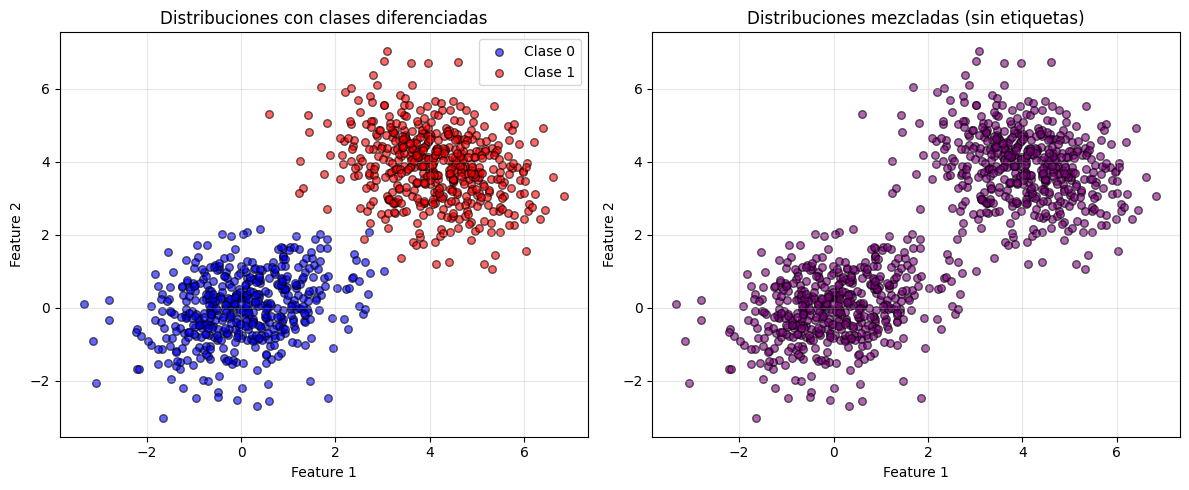

In [10]:
# Visualización de las distribuciones
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Clases diferenciadas por color
ax = axes[0]
ax.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label='Clase 0', alpha=0.6, edgecolors='k', s=30)
ax.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Clase 1', alpha=0.6, edgecolors='k', s=30)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Distribuciones con clases diferenciadas')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Clases mezcladas (mismo color)
ax = axes[1]
ax.scatter(X[:, 0], X[:, 1], c='purple', alpha=0.6, edgecolors='k', s=30)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Distribuciones mezcladas (sin etiquetas)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Mejor gamma: 0.000100
Mejor score de validación: 1.0000


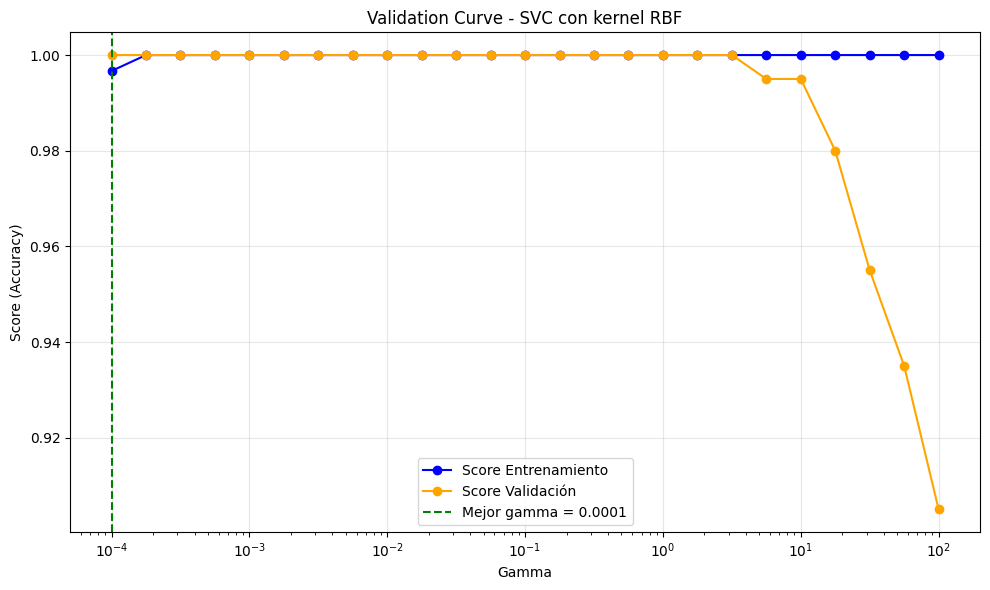

In [11]:
# Grilla de valores de gamma (escala logarítmica)
gamma_grid = np.logspace(-4, 2, 25)

# Calcular validation curve
scores_train, scores_val = compute_validation_curve(
    X_train, y_train, X_val, y_val, gamma_grid
)

# Encontrar mejor gamma
best_gamma, best_score = find_best_gamma(gamma_grid, scores_val)
print(f"Mejor gamma: {best_gamma:.6f}")
print(f"Mejor score de validación: {best_score:.4f}")

# Graficar
fig, ax = plot_validation_curve(gamma_grid, scores_train, scores_val, best_gamma)
plt.show()

### Análisis punto 1:

Para dos distribuciones 2D con diferente media (distancia euclidiana de \sqrt(32)) y varianzas similares (simétricas), podemos ver que al plotearlas la frontera no deberia ser compleja. Por lo que es de esperar que el parámetro gamma del modelo SVC no sea demasiado alto (baja complejidad).

El algoritmo prueba valores de gamma en una escala logaritmica (no espaciados uniformemente), intentando buscar el mejor valor. El resultado fue gamma=0.0001 con un score de validacion de 100%. PERO, curiosamente justo para este valor de gamma que es el más bajo del grid de valores explorados, tiene un score de entrenamiento menor que el de validacion (normalmente es al reves...). Esto puede sugerir que a lo mejor el valor real del mejor gamma puede ser inclusive menor. Sin embargo con este valor es sencillo llegar a un buen score de validación.

Se puede hacer una prueba sencilla de que, al juntar las distribuciones más entre ellas y dispersar mas sus datos, la complejidad debe crecer, y nos da un gamma mayor.

---

## Punto 2 — Learning Curves

Construimos la curva de aprendizaje (score vs tamaño del conjunto de entrenamiento) usando el mejor gamma encontrado.

**Objetivo**: Visualizar cómo mejora el modelo al aumentar los datos de entrenamiento y comparar con `sklearn.model_selection.learning_curve`.

In [12]:
from sklearn.model_selection import ShuffleSplit, learning_curve


def compute_learning_curve_manual(
    X, y, gamma, train_sizes, n_splits=5, val_size=0.2, random_state=42
):
    """
    Calcula la curva de aprendizaje manualmente usando ShuffleSplit.

    Args:
        X: Features, ndarray de shape (n_samples, n_features).
        y: Labels, ndarray de shape (n_samples,).
        gamma: Valor del hiperparámetro gamma para el SVC.
        train_sizes: Fracciones del tamaño de entrenamiento a evaluar (entre 0 y 1).
        n_splits: Número de particiones aleatorias para promediar.
        val_size: Proporción de datos para validación en cada split.
        random_state: Semilla para reproducibilidad.

    Returns:
        train_sizes_abs: Tamaños absolutos de entrenamiento evaluados.
        train_scores: Matriz (n_sizes, n_splits) con scores de entrenamiento.
        val_scores: Matriz (n_sizes, n_splits) con scores de validación.
    """
    n_samples = len(X)
    max_train_size = int(n_samples * (1 - val_size))
    train_sizes_abs = (np.array(train_sizes) * max_train_size).astype(int)

    train_scores = np.zeros((len(train_sizes_abs), n_splits))
    val_scores = np.zeros((len(train_sizes_abs), n_splits))

    splitter = ShuffleSplit(n_splits=n_splits, test_size=val_size, random_state=random_state)

    for split_idx, (train_idx, val_idx) in enumerate(splitter.split(X)):
        X_train_full, y_train_full = X[train_idx], y[train_idx]
        X_val_split, y_val_split = X[val_idx], y[val_idx]

        for size_idx, size in enumerate(train_sizes_abs):
            # Submuestrear el conjunto de entrenamiento
            X_train_subset = X_train_full[:size]
            y_train_subset = y_train_full[:size]

            clf = SVC(kernel='rbf', gamma=gamma)
            clf.fit(X_train_subset, y_train_subset)

            train_scores[size_idx, split_idx] = clf.score(X_train_subset, y_train_subset)
            val_scores[size_idx, split_idx] = clf.score(X_val_split, y_val_split)

    return train_sizes_abs, train_scores, val_scores


def plot_learning_curve(train_sizes, train_scores, val_scores, title=None):
    """
    Grafica la curva de aprendizaje con media y bandas de desviación estándar.

    Args:
        train_sizes: Tamaños de entrenamiento evaluados.
        train_scores: Matriz (n_sizes, n_splits) con scores de entrenamiento.
        val_scores: Matriz (n_sizes, n_splits) con scores de validación.
        title: Título del gráfico (opcional).

    Returns:
        fig, ax: Objetos de matplotlib.
    """
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Curva de entrenamiento
    ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Score Entrenamiento')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.2, color='blue')

    # Curva de validación
    ax.plot(train_sizes, val_mean, 'o-', color='orange', label='Score Validación')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.2, color='orange')

    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('Score (Accuracy)')
    ax.set_title(title or 'Learning Curve')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig, ax


def compare_with_sklearn_learning_curve(X, y, gamma, train_sizes, cv=5):
    """
    Genera la curva de aprendizaje usando sklearn.model_selection.learning_curve.

    Args:
        X: Features, ndarray de shape (n_samples, n_features).
        y: Labels, ndarray de shape (n_samples,).
        gamma: Valor del hiperparámetro gamma para el SVC.
        train_sizes: Fracciones del tamaño de entrenamiento a evaluar.
        cv: Número de folds para cross-validation.

    Returns:
        train_sizes_abs: Tamaños absolutos de entrenamiento.
        train_scores: Matriz con scores de entrenamiento.
        val_scores: Matriz con scores de validación.
    """
    clf = SVC(kernel='rbf', gamma=gamma)

    train_sizes_abs, train_scores, val_scores = learning_curve(
        clf, X, y,
        train_sizes=train_sizes,
        cv=cv,
        scoring='accuracy',
        shuffle=True,
        random_state=42
    )

    return train_sizes_abs, train_scores, val_scores

Datos para learning curve: 800 muestras
Mejor gamma del Punto 1: 0.000100


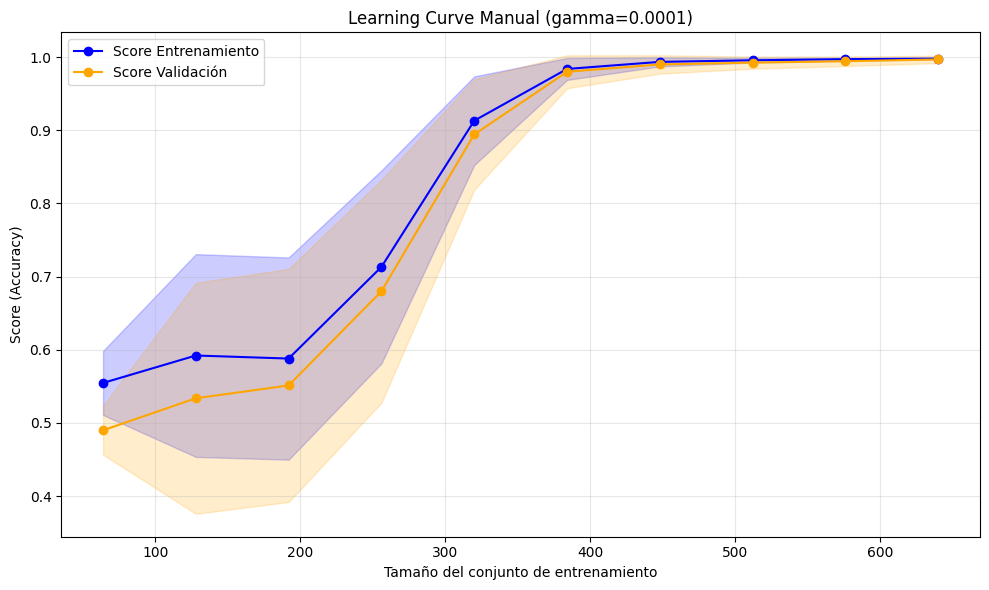

In [13]:
# Combinar train + val para las learning curves (test NO se toca)
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val])

print(f"Datos para learning curve: {len(X_train_val)} muestras")
print(f"Mejor gamma del Punto 1: {best_gamma:.6f}")

# Definir tamaños de entrenamiento a evaluar
train_sizes_fractions = np.linspace(0.1, 1.0, 10)

# Calcular learning curve manual
train_sizes_manual, train_scores_manual, val_scores_manual = compute_learning_curve_manual(
    X_train_val, y_train_val,
    gamma=best_gamma,
    train_sizes=train_sizes_fractions,
    n_splits=10,
    val_size=0.2,
    random_state=42
)

# Graficar
fig, ax = plot_learning_curve(
    train_sizes_manual, train_scores_manual, val_scores_manual,
    title=f'Learning Curve Manual (gamma={best_gamma:.4f})'
)
plt.show()

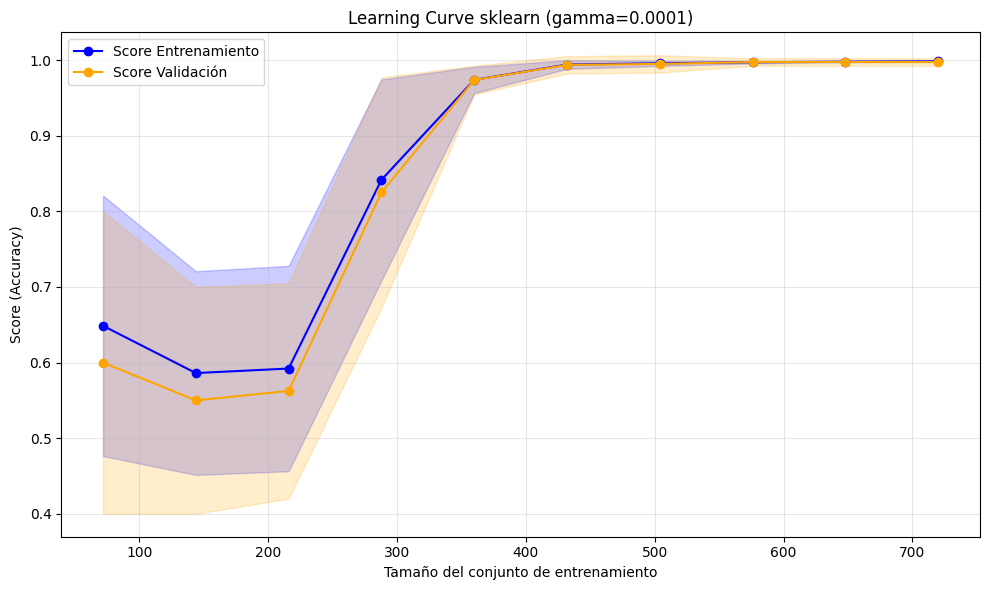

In [15]:
# Learning curve con sklearn para comparación
train_sizes_sklearn, train_scores_sklearn, val_scores_sklearn = compare_with_sklearn_learning_curve(
    X_train_val, y_train_val,
    gamma=best_gamma,
    train_sizes=train_sizes_fractions,
    cv=10
)

# Graficar
fig, ax = plot_learning_curve(
    train_sizes_sklearn, train_scores_sklearn, val_scores_sklearn,
    title=f'Learning Curve sklearn (gamma={best_gamma:.4f})'
)
plt.show()

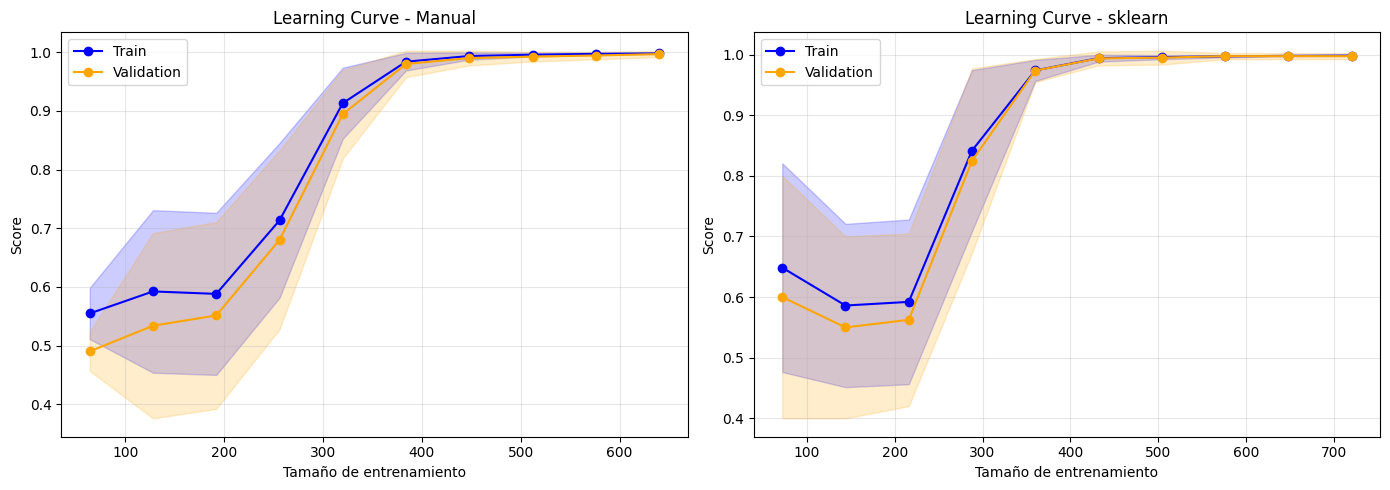

In [16]:
# Comparación lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Manual
ax = axes[0]
train_mean = train_scores_manual.mean(axis=1)
train_std = train_scores_manual.std(axis=1)
val_mean = val_scores_manual.mean(axis=1)
val_std = val_scores_manual.std(axis=1)

ax.plot(train_sizes_manual, train_mean, 'o-', color='blue', label='Train')
ax.fill_between(train_sizes_manual, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
ax.plot(train_sizes_manual, val_mean, 'o-', color='orange', label='Validation')
ax.fill_between(train_sizes_manual, val_mean - val_std, val_mean + val_std, alpha=0.2, color='orange')
ax.set_xlabel('Tamaño de entrenamiento')
ax.set_ylabel('Score')
ax.set_title('Learning Curve - Manual')
ax.legend()
ax.grid(True, alpha=0.3)

# Sklearn
ax = axes[1]
train_mean = train_scores_sklearn.mean(axis=1)
train_std = train_scores_sklearn.std(axis=1)
val_mean = val_scores_sklearn.mean(axis=1)
val_std = val_scores_sklearn.std(axis=1)

ax.plot(train_sizes_sklearn, train_mean, 'o-', color='blue', label='Train')
ax.fill_between(train_sizes_sklearn, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
ax.plot(train_sizes_sklearn, val_mean, 'o-', color='orange', label='Validation')
ax.fill_between(train_sizes_sklearn, val_mean - val_std, val_mean + val_std, alpha=0.2, color='orange')
ax.set_xlabel('Tamaño de entrenamiento')
ax.set_ylabel('Score')
ax.set_title('Learning Curve - sklearn')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis punto 2

Del gráfico de la Learning Curve manual podemos observar: incluso con un tamaño del split de entrenamiento pequeño (~50 muestras), los scores de train y validacion se comportan de forma esperada, aunque con un valor bajo. No me esperaba esto para distribuciones bien separadas. Esto podria implicar que aunque el gamma sea bajo (consistente con la complejidad necesaria para estos datos), aun así el modelo necesita de bastantes datos (>300) para lograr un score mayor a 0.8 tanto en train como en validation.

Es de esperar que al aumentar el tamaño de la muestra los valores de ambos scores aumenten, sin embargo tienen caidas pronunciadas alrededor de 75 y 125. Después de alrededor de 400 datos, ambas curvas de aprendizaje se estabilizan con buenos scores y convergen (comportamiento optimista, el modelo generaliza bien los datos).

Tambien noté que la curva de aprendizaje de sklearn, cuando el split de entrenamiento es bajo (en tamaño), suele tener bandas de error más pequeñas que la curva manual. Mi intuicion me dice que es probable que el algoritmo de sklearn que usa la estrategia de los k-folds reduce enormemente este error. Sin embargo, al aumentar el tamaño de las muestras, ambas curvas se comportan muy similar.

---

## Punto 3 — Demostración de Overfitting y Underfitting

Usando el gamma óptimo encontrado en el Punto 1 (fijo), creamos dos datasets donde el modelo falla:

- **Overfitting**: Clases mezcladas → el modelo memoriza ruido
- **Underfitting**: Estructura no lineal compleja → el gamma suave no puede capturarla

In [17]:
def plot_decision_boundary(clf, X, y, title=None, ax=None):
    """
    Visualiza la frontera de decisión del clasificador junto con los datos.

    Args:
        clf: Clasificador entrenado con método predict.
        X: Features, ndarray de shape (n_samples, 2).
        y: Labels, ndarray de shape (n_samples,).
        title: Título del gráfico (opcional).
        ax: Eje de matplotlib. Si es None, se crea uno nuevo.

    Returns:
        ax: Eje de matplotlib con la visualización.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Crear malla para la frontera de decisión
    margin = 0.5
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Graficar regiones de decisión
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.contour(xx, yy, Z, colors='k', linewidths=0.5)

    # Graficar puntos
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', 
                         edgecolors='k', s=30, alpha=0.7)

    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    if title:
        ax.set_title(title)

    return ax


def demonstrate_scenario(
    mean_0, cov_0, mean_1, cov_1, gamma, n_samples_per_class, scenario_name
):
    """
    Ejecuta el flujo completo para un escenario: genera datos, entrena,
    y muestra frontera de decisión junto con learning curve.

    Args:
        mean_0, cov_0: Parámetros de la distribución de clase 0.
        mean_1, cov_1: Parámetros de la distribución de clase 1.
        gamma: Valor de gamma para el SVC (fijo).
        n_samples_per_class: Número de muestras por clase.
        scenario_name: Nombre del escenario para los títulos.

    Returns:
        fig: Figura con 2 subplots (frontera de decisión y learning curve).
        scores: Diccionario con scores de train y test.
    """
    # Generar datos
    X, y = generate_gaussian_dataset(
        mean_0, cov_0, mean_1, cov_1, n_samples_per_class, random_state=42
    )

    # Split simple para frontera de decisión
    X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Entrenar modelo
    clf = SVC(kernel='rbf', gamma=gamma)
    clf.fit(X_train_demo, y_train_demo)

    train_score = clf.score(X_train_demo, y_train_demo)
    test_score = clf.score(X_test_demo, y_test_demo)

    # Crear figura con 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Subplot 1: Frontera de decisión
    plot_decision_boundary(
        clf, X, y,
        title=f'{scenario_name}\nTrain: {train_score:.3f} | Test: {test_score:.3f}',
        ax=axes[0]
    )

    # Subplot 2: Learning curve
    train_sizes_fractions = np.linspace(0.1, 1.0, 10)
    train_sizes_lc, train_scores_lc, val_scores_lc = compare_with_sklearn_learning_curve(
        X, y, gamma=gamma, train_sizes=train_sizes_fractions, cv=5
    )

    train_mean = train_scores_lc.mean(axis=1)
    train_std = train_scores_lc.std(axis=1)
    val_mean = val_scores_lc.mean(axis=1)
    val_std = val_scores_lc.std(axis=1)

    ax = axes[1]
    ax.plot(train_sizes_lc, train_mean, 'o-', color='blue', label='Train')
    ax.fill_between(train_sizes_lc, train_mean - train_std, train_mean + train_std,
                    alpha=0.2, color='blue')
    ax.plot(train_sizes_lc, val_mean, 'o-', color='orange', label='Validation')
    ax.fill_between(train_sizes_lc, val_mean - val_std, val_mean + val_std,
                    alpha=0.2, color='orange')
    ax.set_xlabel('Tamaño de entrenamiento')
    ax.set_ylabel('Score')
    ax.set_title(f'Learning Curve - {scenario_name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.4, 1.05)

    plt.tight_layout()

    return fig, {'train': train_score, 'test': test_score}

ESCENARIO: OVERFITTING
Clase 0: media=[0 0], varianza=1.5
Clase 1: media=[1. 1.], varianza=1.5
Gamma ALTO: 10 (genera fronteras muy complejas)


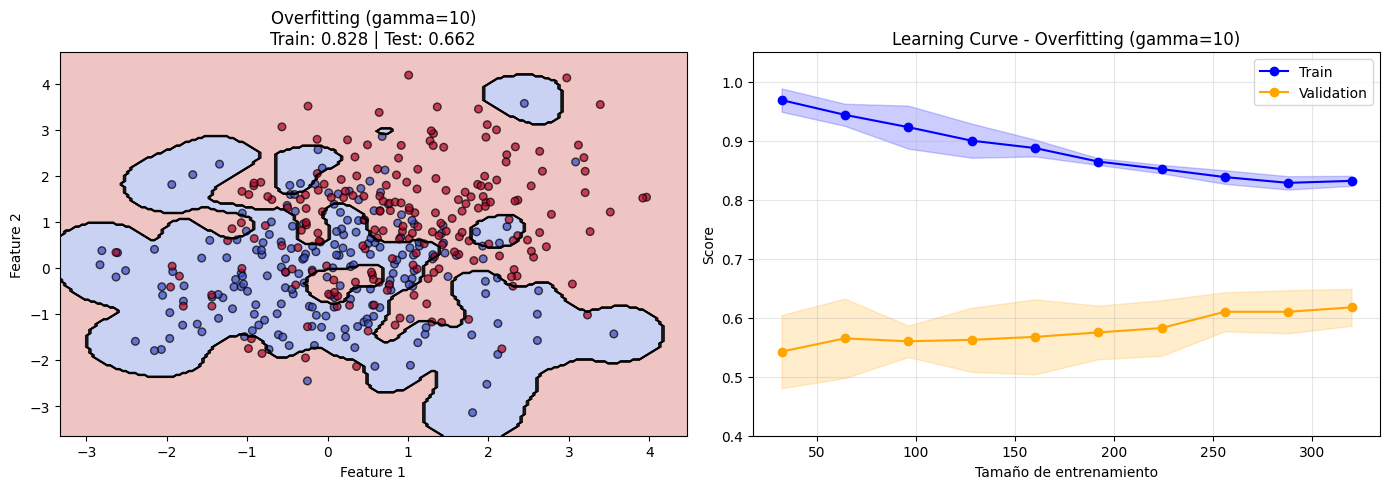


Score Train: 0.828
Score Test: 0.662
Gap (Train - Test): 0.166


In [20]:
# === ESCENARIO 1: OVERFITTING ===

mean_0_over = np.array([0, 0])
cov_0_over = np.array([[1.5, 0], [0, 1.5]])

mean_1_over = np.array([1.0, 1.0])  # Cercano a clase 0
cov_1_over = np.array([[1.5, 0], [0, 1.5]])

gamma_high = 10  # Gamma alto → frontera muy compleja → overfitting

print("ESCENARIO: OVERFITTING")
print("="*50)
print(f"Clase 0: media={mean_0_over}, varianza={cov_0_over[0,0]}")
print(f"Clase 1: media={mean_1_over}, varianza={cov_1_over[0,0]}")
print(f"Gamma ALTO: {gamma_high} (genera fronteras muy complejas)")

fig_over, scores_over = demonstrate_scenario(
    mean_0_over, cov_0_over, mean_1_over, cov_1_over,
    gamma=gamma_high,
    n_samples_per_class=200,
    scenario_name='Overfitting (gamma=10)'
)
plt.show()

print(f"\nScore Train: {scores_over['train']:.3f}")
print(f"Score Test: {scores_over['test']:.3f}")
print(f"Gap (Train - Test): {scores_over['train'] - scores_over['test']:.3f}")

ESCENARIO: UNDERFITTING
Clase 0: media=[0 0], varianza=0.5 (compacta)
Clase 1: media=[0 0], varianza=5 (dispersa)
Gamma BAJO: 0.001 (genera fronteras casi lineales)

La clase 0 está en el centro, la clase 1 la rodea.
La frontera óptima sería un CÍRCULO, pero gamma bajo
solo puede generar fronteras casi lineales.


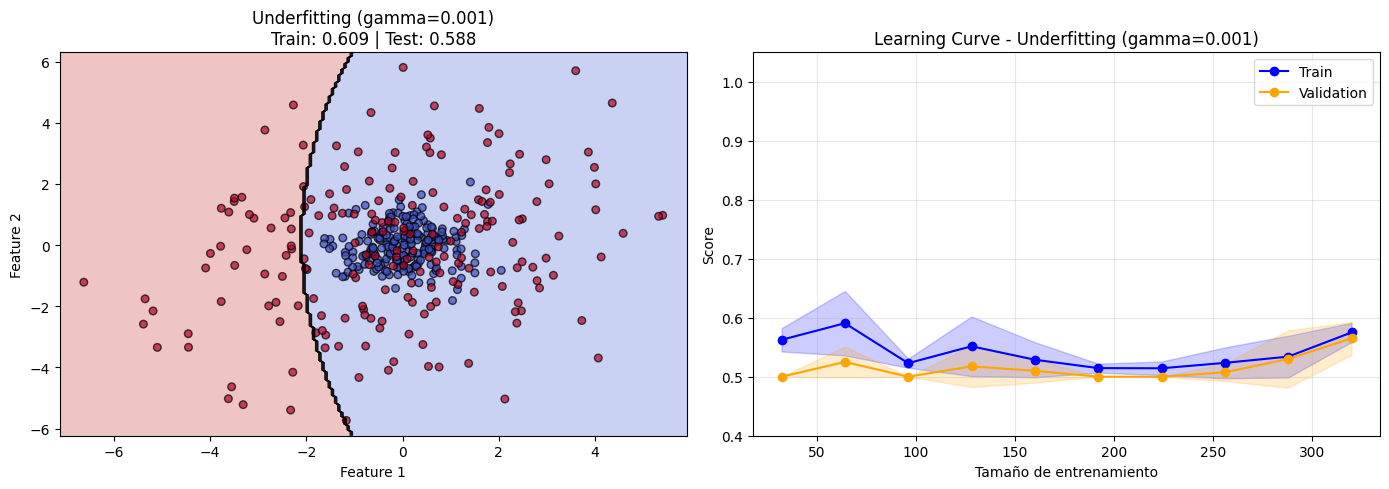


Score Train: 0.609
Score Test: 0.588
Gap (Train - Test): 0.022

→ Ambos scores bajos indica UNDERFITTING: el modelo es muy simple.


In [19]:
# === ESCENARIO 2: UNDERFITTING ===
# Usamos un gamma MUY BAJO (o el óptimo del Punto 1)
# La estructura circular requiere fronteras complejas que gamma bajo no puede generar

mean_0_under = np.array([0, 0])
cov_0_under = np.array([[0.5, 0], [0, 0.5]])  # Compacta en el centro

mean_1_under = np.array([0, 0])  # Misma media
cov_1_under = np.array([[5, 0], [0, 5]])  # Dispersa, rodea a clase 0

gamma_low = 0.001  # Gamma bajo → frontera muy simple → underfitting

print("ESCENARIO: UNDERFITTING")
print("="*50)
print(f"Clase 0: media={mean_0_under}, varianza={cov_0_under[0,0]} (compacta)")
print(f"Clase 1: media={mean_1_under}, varianza={cov_1_under[0,0]} (dispersa)")
print(f"Gamma BAJO: {gamma_low} (genera fronteras casi lineales)")
print()
print("La clase 0 está en el centro, la clase 1 la rodea.")
print("La frontera óptima sería un CÍRCULO, pero gamma bajo")
print("solo puede generar fronteras casi lineales.")

fig_under, scores_under = demonstrate_scenario(
    mean_0_under, cov_0_under, mean_1_under, cov_1_under,
    gamma=gamma_low,
    n_samples_per_class=200,
    scenario_name='Underfitting (gamma=0.001)'
)
plt.show()

print(f"\nScore Train: {scores_under['train']:.3f}")
print(f"Score Test: {scores_under['test']:.3f}")
print(f"Gap (Train - Test): {scores_under['train'] - scores_under['test']:.3f}")
print("\n→ Ambos scores bajos indica UNDERFITTING: el modelo es muy simple.")

### Análisis punto 3


#### Escenario de overfitting:
Para simular overfitting basta con elegir un gamma más alto que abstraiga una complejidad mayor de la que realmente se requiere para separar los datos. El modelo empieza a memorizar el ruido. Este fenómeno se puede apreciar en las curvas de aprendizaje pues las curvas de entrenamiento y validacion nunca convergen y se separan enormemente.

Una solución para este escenario es directamente reducir la complejidad del modelo: explorar valores de gamma más bajos, además de, si es posible (normalmente es complicado), aumentar el tamaño de las muestras.

### Escenario de underfitting:
Cuando las clases (distribuciones) estan mas mezcladas, el modelo requiere de mayor complejidad. Usar un gamma bajo hará que el modelo cree fronteras muy suaves y simples (casi lineales) que no capturan bien la complejidad de los datos. En este caso, podemos identificar el underfitting porque en las curvas de aprendizaje, tanto train como validation convergen en valores bajos del score.

Las soluciones para este caso son complementarias a la del overfitting. En primera instancia, aumentar el gamma para ver si el modelo puede dibujar una frontera más compleja, pero sin memorizar el ruido. Si no es posible, se puede intentar añadir más features que ayuden a diferenciar mejor los grupos (esto tambien es aumentar la complejidad).

### Análisis de Resultados (CLAUDE)

| Escenario | Gamma | Score Train | Score Test | Diagnóstico |
|-----------|-------|-------------|------------|-------------|
| **Original (Punto 1)** | óptimo | ~1.0 | ~1.0 | Modelo bien calibrado |
| **Overfitting** | alto (10) | Alto | Bajo | Gap grande → memoriza ruido |
| **Underfitting** | bajo (0.001) | Bajo | Bajo | Ambos bajos → modelo muy simple |

---
**Soluciones:**

| Problema | Solución |
|----------|----------|
| Overfitting | Reducir gamma, más datos, regularización (C más bajo) |
| Underfitting | Aumentar gamma, modelo más complejo, más features |